# Week 2 — Tesla EV Delivery & Production Forecasting

**Goal** — Build a complete ML + Time Series forecasting pipeline on Tesla's global delivery dataset (2015–2025).

**Dataset** — Tesla.csv (Deliveries, Production, Pricing, Regional breakdown)


In [31]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Stats
from scipy.stats import f_oneway, chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

import joblib

## 1. Load & Inspect Dataset

In [33]:
df = pd.read_csv('Tesla.csv')
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


In [34]:
print("Rows x Cols :", df.shape)
print("Total cells :", df.size)

Rows x Cols : (2640, 12)
Total cells : 31680


In [35]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [36]:
print("Null values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Null values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows: 0


## 2. Define Feature Groups

In [37]:
continuous_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                   'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

categorical_cols = ['Region', 'Model', 'Source_Type']

time_cols = ['Year', 'Month']

## 3. Exploratory Data Analysis

### 3.1 Numerical Summary

In [38]:
df[continuous_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Estimated_Deliveries,2640.0,9922.20,3935.95,48.00,7292.00,9857.00,12510.25,25704.00
Production_Units,2640.0,10655.85,4260.60,50.00,7828.25,10546.50,13469.00,28939.00
Avg_Price_USD,2640.0,84907.34,20123.26,50003.70,67726.36,85058.51,102373.04,119965.36
Battery_Capacity_kWh,2640.0,87.06,20.84,60.00,75.00,82.00,100.00,120.00
Range_km,2640.0,500.26,120.87,330.00,418.00,470.00,586.25,719.00
CO2_Saved_tons,2640.0,744.08,353.22,3.07,499.62,699.52,943.76,2548.55
Charging_Stations,2640.0,8932.13,3469.57,3002.00,5897.75,8901.50,11938.00,14996.00


### 3.2 Skewness & Kurtosis

In [39]:
print(f"{'Column':<25} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 47)
for col in continuous_cols:
    print(f"{col:<25} {df[col].skew():>10.3f} {df[col].kurt():>10.3f}")

Column                      Skewness   Kurtosis
-----------------------------------------------
Estimated_Deliveries           0.088     -0.061
Production_Units               0.130      0.016
Avg_Price_USD                 -0.000     -1.181
Battery_Capacity_kWh           0.340     -1.112
Range_km                       0.342     -1.084
CO2_Saved_tons                 0.660      0.613
Charging_Stations              0.022     -1.207


### 3.3 Histograms

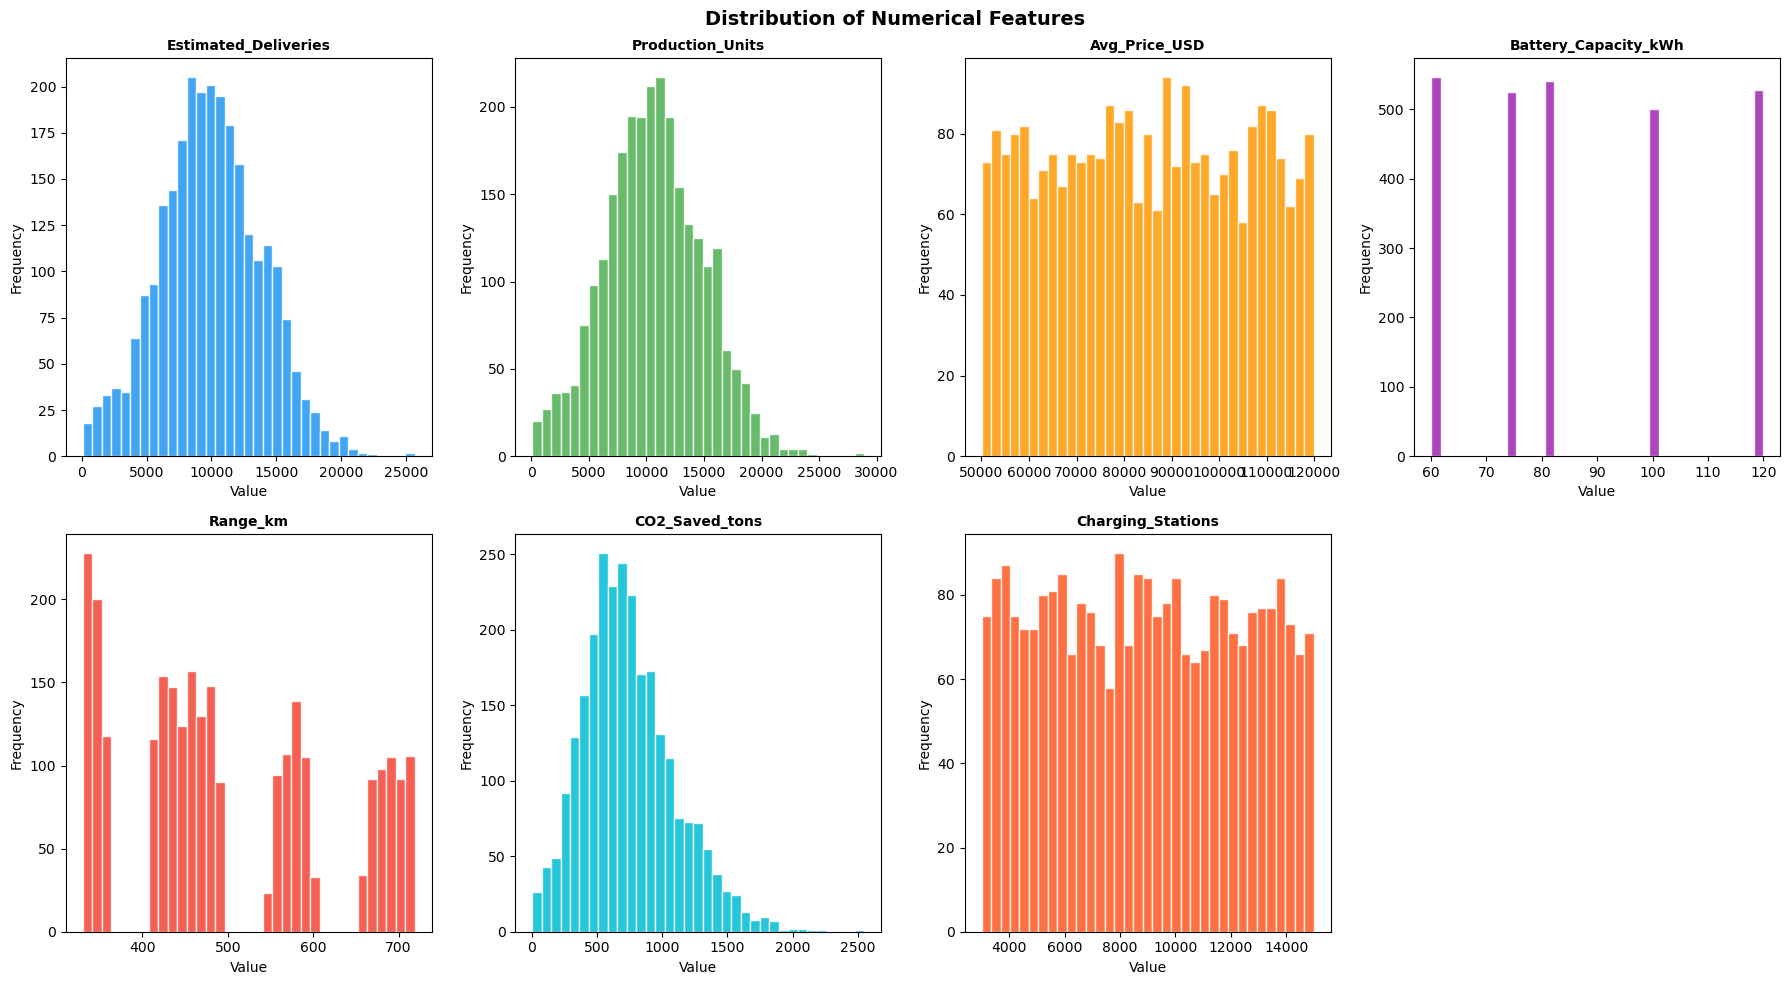

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#FF5722']

for i, col in enumerate(continuous_cols):
    axes[i].hist(df[col], bins=35, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)
plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Boxplots — Outlier Check

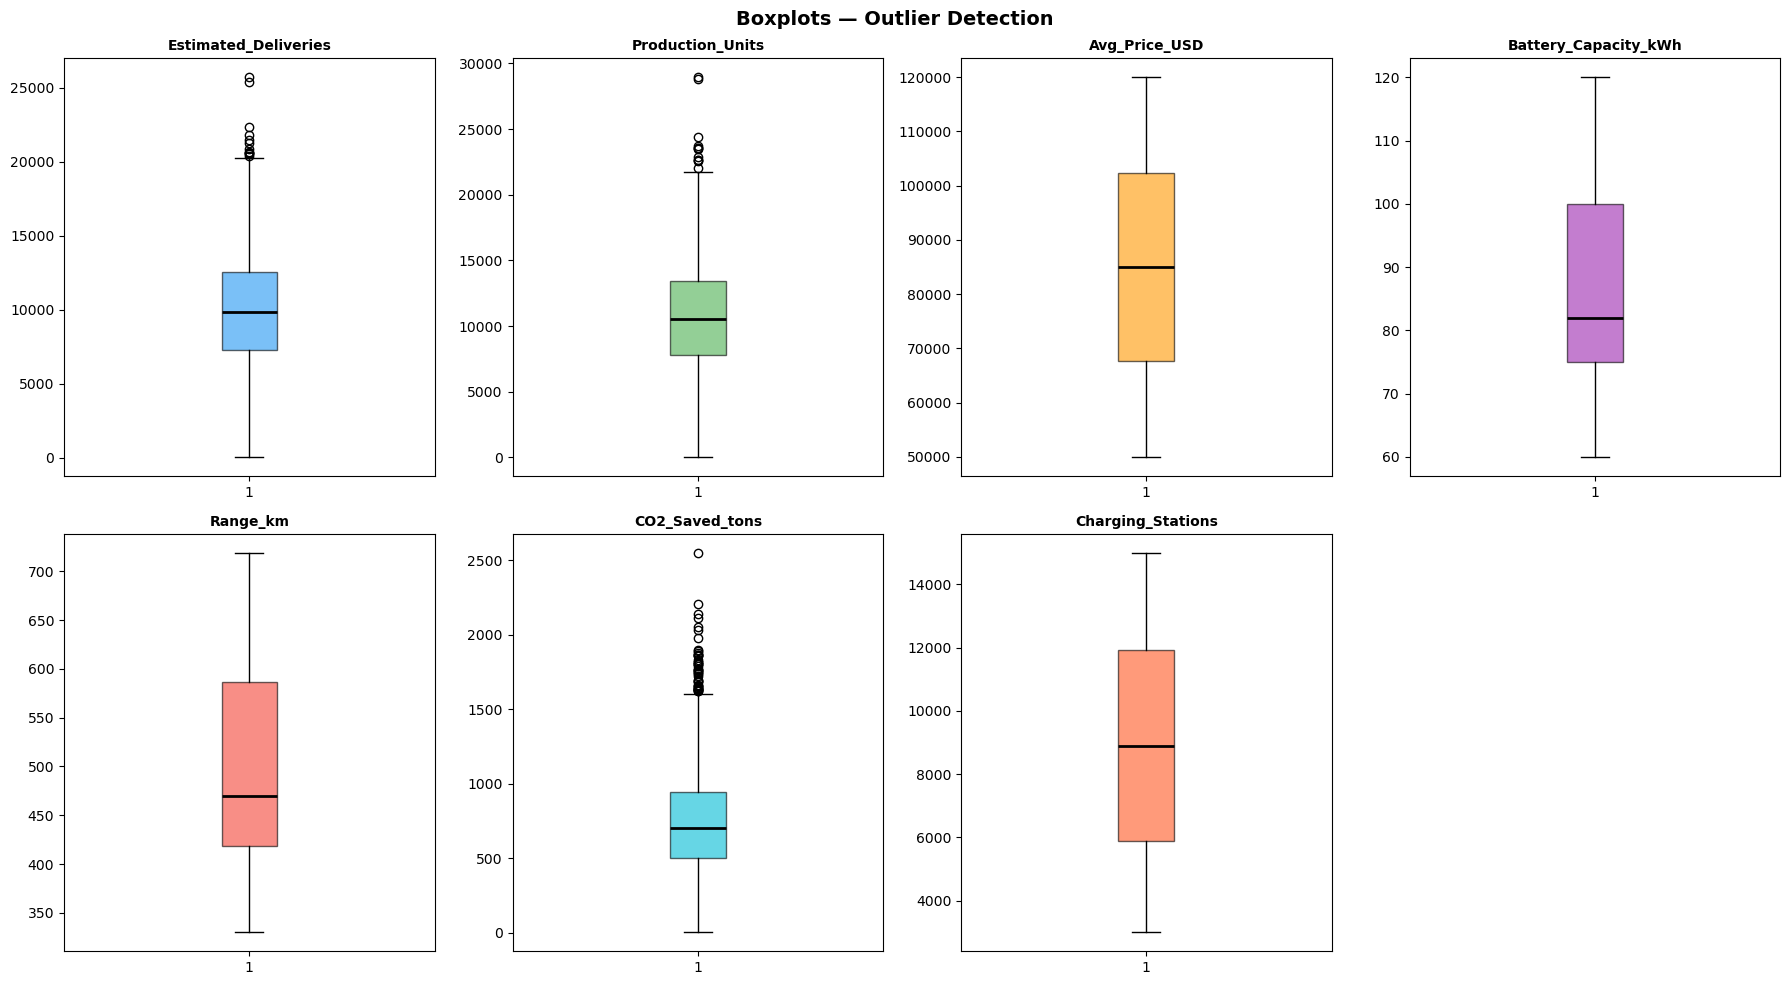

In [41]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    bp = axes[i].boxplot(df[col], patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(colors[i])
    bp['boxes'][0].set_alpha(0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 IQR Outlier Count

In [42]:
print(f"{'Column':<28} {'Outliers':>8}")
print("-" * 38)
for col in continuous_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)].shape[0]
    print(f"{col:<28} {n:>8}")

Column                       Outliers
--------------------------------------
Estimated_Deliveries               12
Production_Units                   12
Avg_Price_USD                       0
Battery_Capacity_kWh                0
Range_km                            0
CO2_Saved_tons                     45
Charging_Stations                   0


### 3.6 Categorical Features

In [43]:
df[categorical_cols].describe().T

,count,unique,top,freq
Region,2640,4,Europe,660
Model,2640,5,Model S,528
Source_Type,2640,3,Interpolated (Month),884


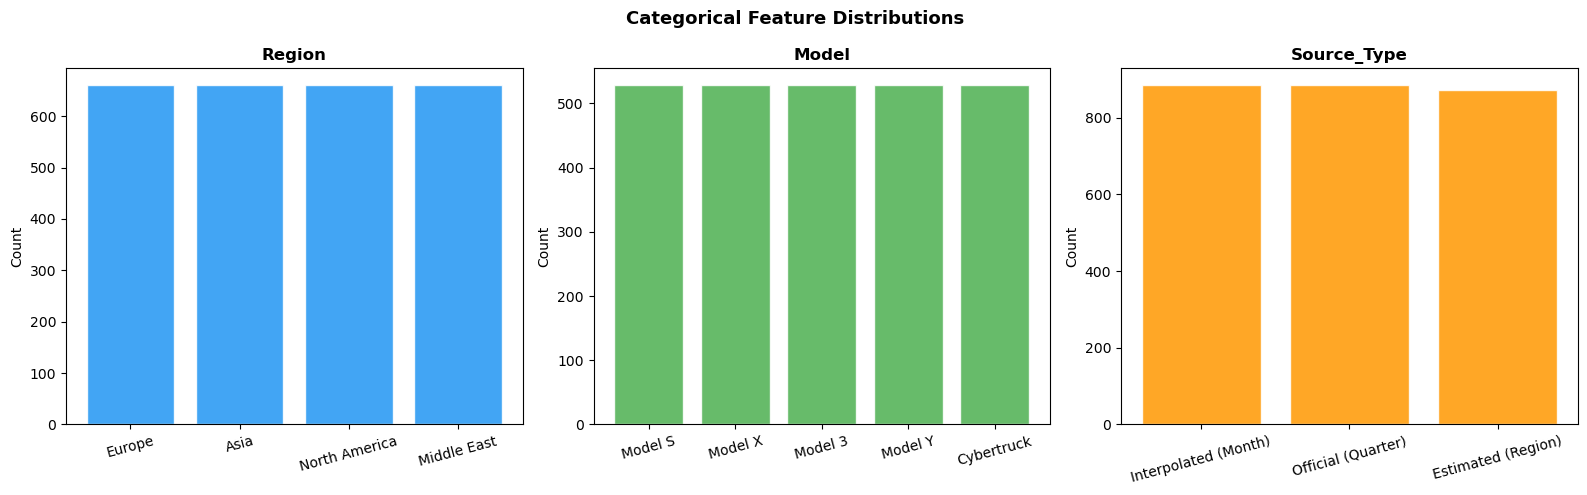

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, col in enumerate(categorical_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=cat_colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

All categorical features are balanced — no class imbalance detected.

### 3.7 Correlation Heatmap

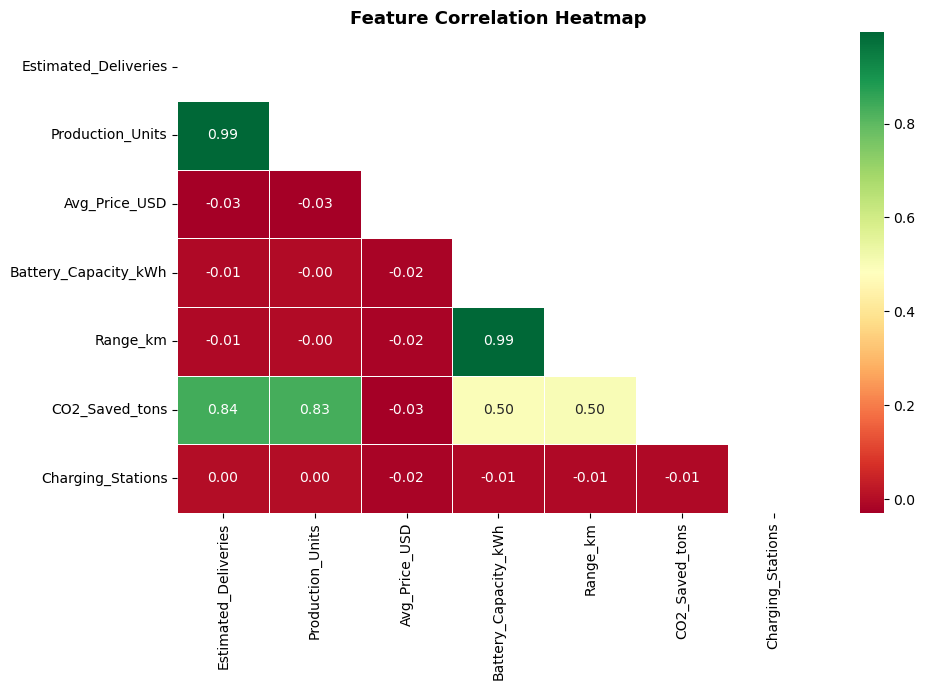

In [45]:
plt.figure(figsize=(10, 7))
corr = df[continuous_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, mask=mask)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

`Estimated_Deliveries` & `Production_Units` are highly correlated (0.99), and so are `Battery_Capacity_kWh` & `Range_km` (0.99) — multicollinearity is present.

## 4. Statistical Tests

### 4.1 ANOVA — Deliveries across Regions

In [46]:
summary = df.groupby('Region')['Estimated_Deliveries'].agg(['mean','median','std','count'])
print(summary.round(2))

groups = [g['Estimated_Deliveries'].values for _, g in df.groupby('Region')]
f, p = f_oneway(*groups)
print(f"\nF-Statistic: {f:.4f}  |  P-Value: {p:.4f}")

tukey = pairwise_tukeyhsd(df['Estimated_Deliveries'], df['Region'])
print(tukey)

                   mean   median      std  count
Region                                          
Asia            9908.99   9869.0  3857.89    660
Europe          9839.45   9675.0  4072.52    660
Middle East    10148.55  10199.5  3911.55    660
North America   9791.81   9694.0  3897.82    660

F-Statistic: 1.0689  |  P-Value: 0.3610
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower    upper   reject
--------------------------------------------------------------------
       Asia        Europe  -69.5455 0.9886  -626.503 487.4121  False
       Asia   Middle East  239.5606  0.686  -317.397 796.5182  False
       Asia North America -117.1864  0.949 -674.1439 439.7712  False
     Europe   Middle East  309.1061 0.4827 -247.8515 866.0636  False
     Europe North America  -47.6409 0.9962 -604.5985 509.3167  False
Middle East North America  -356.747 0.3526 -913.7045 200.2106  False
--------------------------------------------

ANOVA result (p > 0.05): No significant difference in deliveries across regions.

### 4.2 Chi-Square — Region vs Source Type

In [47]:
ct = pd.crosstab(df['Region'], df['Source_Type'])
print(ct)
print()
print(ct.div(ct.sum(axis=1), axis=0).round(3))

chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi2={chi2:.4f}  P-Value={p:.4f}  DOF={dof}")

Source_Type    Estimated (Region)  Interpolated (Month)  Official (Quarter)
Region                                                                     
Asia                          214                   209                 237
Europe                        215                   219                 226
Middle East                   234                   212                 214
North America                 209                   244                 207

Source_Type    Estimated (Region)  Interpolated (Month)  Official (Quarter)
Region                                                                     
Asia                        0.324                 0.317               0.359
Europe                      0.326                 0.332               0.342
Middle East                 0.355                 0.321               0.324
North America               0.317                 0.370               0.314

Chi2=7.4705  P-Value=0.2795  DOF=6


Chi-Square (p > 0.05): Region and Source_Type are statistically independent.

## 5. Feature Engineering

Dropping `Battery_Capacity_kWh` — highly correlated with `Range_km`.

In [48]:
keep_cols = ['Avg_Price_USD', 'Range_km', 'Charging_Stations',
             'Year', 'Month', 'Region', 'Model', 'Source_Type',
             'Production_Units', 'Estimated_Deliveries']

data = df[keep_cols].copy()

train_df, test_df = train_test_split(data, test_size=0.2, random_state=17)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")

Train: (2112, 10)  |  Test: (528, 10)


In [49]:
# Save for ARIMA later
ref_year  = train_df['Year'].min()

price_thresholds = [
    train_df['Avg_Price_USD'].min(),
    train_df['Avg_Price_USD'].quantile(0.33),
    train_df['Avg_Price_USD'].quantile(0.66),
    train_df['Avg_Price_USD'].max()
]

def engineer_features(frame, ref_year, price_thresholds):
    f = frame.copy()
    f['Elapsed_Years']   = f['Year'] - ref_year
    f['Fiscal_Quarter']  = f['Month'].apply(lambda m: (m - 1) // 3 + 1)
    f['Price_Band']      = pd.cut(f['Avg_Price_USD'], bins=price_thresholds,
                                   labels=['Economy','Standard','Premium'],
                                   include_lowest=True)
    f['Segment']         = f['Region'] + '_' + f['Model']
    f.drop(columns=['Year','Month','Avg_Price_USD'], inplace=True)
    return f

train_df = engineer_features(train_df, ref_year, price_thresholds)
test_df  = engineer_features(test_df,  ref_year, price_thresholds)

### 5.1 Lag Features

In [50]:
def make_lags(frame):
    frame = frame.sort_values(['Segment','Elapsed_Years','Fiscal_Quarter']).reset_index(drop=True)
    frame['delivery_lag1']    = frame.groupby('Segment')['Estimated_Deliveries'].shift(1)
    frame['delivery_lag2']    = frame.groupby('Segment')['Estimated_Deliveries'].shift(2)
    frame['delivery_roll3']   = (frame.groupby('Segment')['Estimated_Deliveries']
                                  .transform(lambda x: x.shift(1).rolling(3).mean()))
    return frame

combined = pd.concat([train_df, test_df]).reset_index(drop=True)
combined = make_lags(combined)

train_df = combined.iloc[:len(train_df)].dropna().reset_index(drop=True)
test_df  = combined.iloc[len(train_df):].reset_index(drop=True)

for c in ['delivery_lag1','delivery_lag2','delivery_roll3']:
    test_df[c] = test_df[c].fillna(train_df[c].median())

print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")

Train: (2063, 14)  |  Test: (577, 14)


## 6. Encoding

### 6.1 One-Hot Encoding

In [51]:
ohe_features = ['Region', 'Source_Type', 'Fiscal_Quarter', 'Price_Band']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(train_df[ohe_features])

def encode_ohe(frame, ohe, cols):
    arr = pd.DataFrame(ohe.transform(frame[cols]),
                       columns=ohe.get_feature_names_out(cols),
                       index=frame.index)
    return pd.concat([frame.drop(columns=cols), arr], axis=1)

train_df = encode_ohe(train_df, ohe, ohe_features)
test_df  = encode_ohe(test_df,  ohe, ohe_features)
print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")

Train: (2063, 20)  |  Test: (577, 20)


### 6.2 Target Encoding

In [52]:
TARGET = 'Estimated_Deliveries'

te_model   = TargetEncoder(random_state=17, cv=3)
te_segment = TargetEncoder(random_state=17, cv=3)

train_df['Model']   = te_model.fit_transform(train_df[['Model']],   train_df[TARGET])
train_df['Segment'] = te_segment.fit_transform(train_df[['Segment']], train_df[TARGET])

test_df['Model']   = te_model.transform(test_df[['Model']])
test_df['Segment'] = te_segment.transform(test_df[['Segment']])

for frame in [train_df, test_df]:
    b_cols = frame.select_dtypes(include='bool').columns
    frame[b_cols] = frame[b_cols].astype(int)

print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")

Train: (2063, 20)  |  Test: (577, 20)


## 7. Model Training & Evaluation

In [53]:
X_tr = train_df.drop(columns=TARGET)
y_tr = train_df[TARGET]
X_te = test_df.drop(columns=TARGET)
y_te = test_df[TARGET]
print(f"X_train: {X_tr.shape}  |  X_test: {X_te.shape}")

X_train: (2063, 19)  |  X_test: (577, 19)


In [54]:
def get_scores(name, actual, predicted):
    return {
        'Model': name,
        'R2'  : round(r2_score(actual, predicted), 4),
        'MAE' : round(mean_absolute_error(actual, predicted), 2),
        'RMSE': round(np.sqrt(mean_squared_error(actual, predicted)), 2)
    }

In [55]:
alpha_values = [0.01, 0.1, 1, 10, 50, 100, 500, 1000]

# Linear Regression
lr = Pipeline([('sc', StandardScaler()), ('reg', LinearRegression())])
lr.fit(X_tr, y_tr)

# Ridge
ridge_gs = GridSearchCV(
    Pipeline([('sc', StandardScaler()), ('reg', Ridge())]),
    {'reg__alpha': alpha_values}, scoring='r2', cv=5, n_jobs=-1)
ridge_gs.fit(X_tr, y_tr)

# Lasso
lasso_gs = GridSearchCV(
    Pipeline([('sc', StandardScaler()), ('reg', Lasso(max_iter=8000))]),
    {'reg__alpha': alpha_values}, scoring='r2', cv=5, n_jobs=-1)
lasso_gs.fit(X_tr, y_tr)

print(f"Ridge best alpha : {ridge_gs.best_params_}")
print(f"Lasso best alpha : {lasso_gs.best_params_}")

Ridge best alpha : {'reg__alpha': 0.01}
Lasso best alpha : {'reg__alpha': 10}


### 7.1 Test Set Results

In [56]:
all_results = []
all_results.append(get_scores('LinearRegression', y_te, lr.predict(X_te)))
all_results.append(get_scores('Ridge',            y_te, ridge_gs.best_estimator_.predict(X_te)))
all_results.append(get_scores('Lasso',            y_te, lasso_gs.best_estimator_.predict(X_te)))

leaderboard = pd.DataFrame(all_results).sort_values('R2', ascending=False).reset_index(drop=True)
print(leaderboard.to_string(index=False))

           Model     R2    MAE   RMSE
           Lasso 0.9890 336.62 407.08
LinearRegression 0.9886 341.42 414.58
           Ridge 0.9886 341.42 414.58


### 7.2 Cross-Validation (5-Fold)

In [57]:
pipe_map = {
    'LinearRegression': lr,
    'Ridge'           : ridge_gs.best_estimator_,
    'Lasso'           : lasso_gs.best_estimator_
}
for name, pipe in pipe_map.items():
    cv = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name:<20}  CV R² = {cv.mean():.4f} ± {cv.std():.4f}")

LinearRegression      CV R² = 0.9882 ± 0.0006
Ridge                 CV R² = 0.9882 ± 0.0006
Lasso                 CV R² = 0.9883 ± 0.0006


### 7.3 Lasso — Non-Zero Coefficients

In [58]:
lasso_coef = pd.Series(
    lasso_gs.best_estimator_.named_steps['reg'].coef_,
    index=X_tr.columns
)
print("Active features:")
print(lasso_coef[lasso_coef != 0].sort_values(ascending=False).to_string())
print()
print("Zeroed out by Lasso:", lasso_coef[lasso_coef == 0].index.tolist())

Active features:
Production_Units       3908.546172
Price_Band_Standard       6.183339
Region_Europe            -1.694604
Range_km                 -5.110915
delivery_roll3           -7.619722

Zeroed out by Lasso: ['Charging_Stations', 'Model', 'Elapsed_Years', 'Segment', 'delivery_lag1', 'delivery_lag2', 'Region_Middle East', 'Region_North America', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)', 'Fiscal_Quarter_2', 'Fiscal_Quarter_3', 'Fiscal_Quarter_4', 'Price_Band_Premium']


### 7.4 Residual Analysis — Best Model (Ridge)

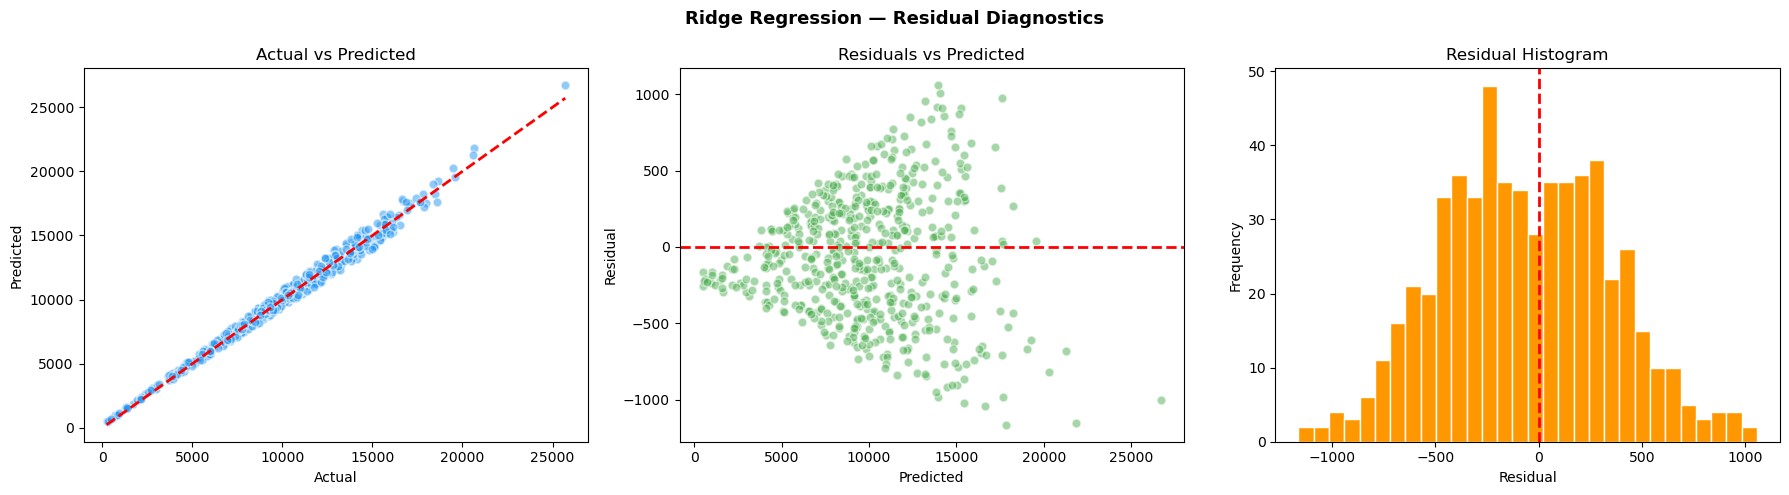

Residual Mean : -68.9993
Residual Std  : 409.1477


In [59]:
top_model = ridge_gs.best_estimator_
preds     = top_model.predict(X_te)
resid     = y_te - preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ridge Regression — Residual Diagnostics', fontsize=13, fontweight='bold')

axes[0].scatter(y_te, preds, alpha=0.5, color='#2196F3', edgecolors='white', s=40)
axes[0].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
axes[0].set(title='Actual vs Predicted', xlabel='Actual', ylabel='Predicted')

axes[1].scatter(preds, resid, alpha=0.5, color='#4CAF50', edgecolors='white', s=40)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set(title='Residuals vs Predicted', xlabel='Predicted', ylabel='Residual')

axes[2].hist(resid, bins=30, color='#FF9800', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', lw=2)
axes[2].set(title='Residual Histogram', xlabel='Residual', ylabel='Frequency')

plt.tight_layout()
plt.show()

print(f"Residual Mean : {resid.mean():.4f}")
print(f"Residual Std  : {resid.std():.4f}")

## 8. Time Series Forecasting

In [60]:
monthly_ts = (
    df.groupby(['Year','Month'])['Estimated_Deliveries']
    .sum().reset_index()
)
monthly_ts['Date'] = pd.to_datetime(
    monthly_ts[['Year','Month']].assign(day=1))
ts = monthly_ts.set_index('Date')['Estimated_Deliveries'].sort_index()

adf_result = adfuller(ts)
stat, p_adf = adf_result[0], adf_result[1]
print(f"ADF Statistic : {stat:.4f}")
print(f"ADF P-Value   : {p_adf:.4f}")
print("Status        :", "Stationary ✓" if p_adf < 0.05 else "Non-Stationary")

ADF Statistic : -8.8810
ADF P-Value   : 0.0000
Status        : Stationary ✓


In [61]:
test_ref = (
    df.loc[test_df.index]
    .groupby(['Year','Month'])['Estimated_Deliveries']
    .sum().reset_index()
)
test_ref['Date'] = pd.to_datetime(test_ref[['Year','Month']].assign(day=1))
ts_test = test_ref.set_index('Date')['Estimated_Deliveries'].sort_index()

n_steps      = len(ts_test)
ts_train_cut = ts.iloc[:-n_steps] if n_steps > 0 else ts

arima_mdl    = ARIMA(ts_train_cut, order=(1,1,1)).fit()
arima_fc     = arima_mdl.forecast(steps=n_steps)
arima_fc.index = ts_test.index

print("ARIMA Forecast preview:")
print(arima_fc.head().round())

ARIMA Forecast preview:
Date
2015-02-01    183180.0
2015-03-01    183180.0
2015-04-01    183180.0
2015-05-01    183180.0
2015-06-01    183180.0
Name: predicted_mean, dtype: float64


In [62]:
ml_pred_vals = pd.Series(top_model.predict(X_te).astype(float), index=test_df.index)

ml_monthly = (
    df.loc[test_df.index, ['Year','Month']]
    .assign(ml=ml_pred_vals.values)
    .groupby(['Year','Month'])['ml'].sum().reset_index()
)
ml_monthly['Date'] = pd.to_datetime(ml_monthly[['Year','Month']].assign(day=1))
ml_ts = ml_monthly.set_index('Date')['ml'].sort_index()

idx = arima_fc.index.intersection(ml_ts.index).intersection(ts_test.index)
y_act   = ts_test.loc[idx]
y_arima = arima_fc.loc[idx]
y_ml    = ml_ts.loc[idx]

def compare(label, actual, pred):
    return {'Model': label,
            'MAE' : round(mean_absolute_error(actual, pred), 2),
            'RMSE': round(np.sqrt(mean_squared_error(actual, pred)), 2),
            'R2'  : round(r2_score(actual, pred), 4)}

cmp = pd.DataFrame([compare('ARIMA', y_act, y_arima), compare('ML Ridge', y_act, y_ml)])

r_a = cmp.loc[cmp['Model']=='ARIMA',    'RMSE'].iloc[0]
r_m = cmp.loc[cmp['Model']=='ML Ridge', 'RMSE'].iloc[0]
total = r_a + r_m
w_ml, w_ar = r_a/total, r_m/total
ensemble = w_ml*y_ml + w_ar*y_arima

cmp = pd.concat([cmp, pd.DataFrame([compare('Ensemble', y_act, ensemble)])], ignore_index=True)
print(cmp.to_string(index=False))

best_fc = cmp.loc[cmp['RMSE'].idxmin(), 'Model']
print(f"\nBest Forecaster: {best_fc}")

   Model       MAE      RMSE       R2
   ARIMA 139502.06 140888.61 -50.0566
ML Ridge   8813.81  11552.76   0.6567
Ensemble  13221.34  15388.90   0.3909

Best Forecaster: ML Ridge


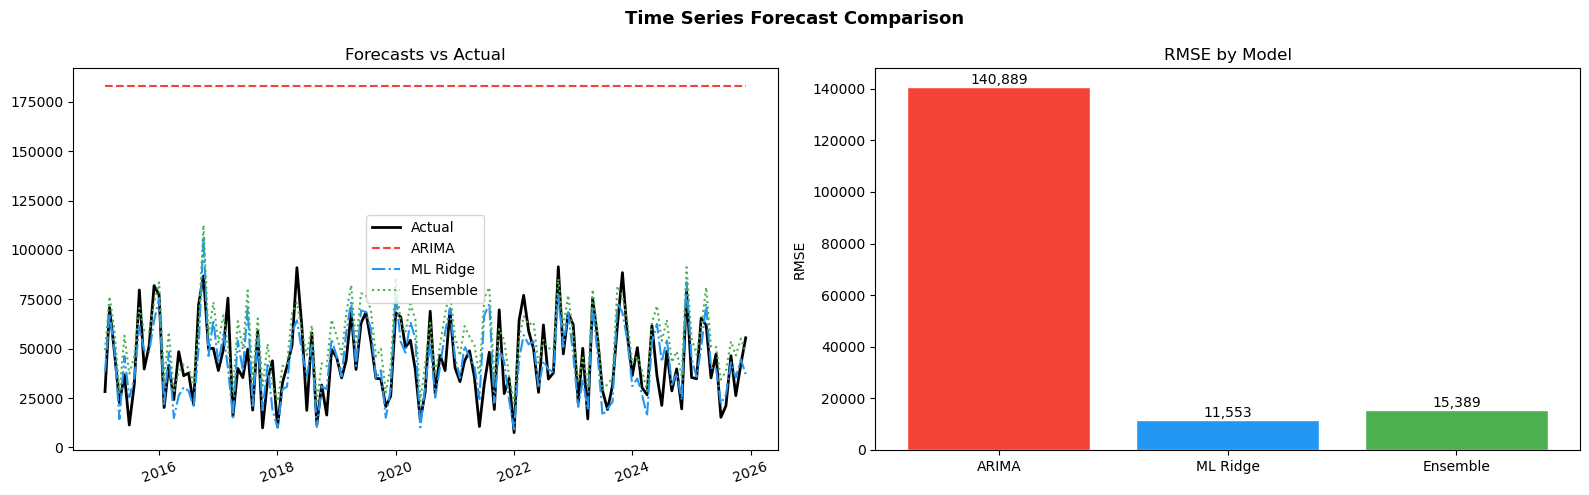

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Time Series Forecast Comparison', fontsize=13, fontweight='bold')

axes[0].plot(y_act.index,      y_act,     label='Actual',   lw=2, color='black')
axes[0].plot(y_arima.index,    y_arima,   label='ARIMA',    lw=1.5, linestyle='--',  color='#F44336')
axes[0].plot(y_ml.index,       y_ml,      label='ML Ridge', lw=1.5, linestyle='-.',  color='#2196F3')
axes[0].plot(ensemble.index,   ensemble,  label='Ensemble', lw=1.5, linestyle=':',   color='#4CAF50')
axes[0].set_title('Forecasts vs Actual')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=20)

bar_colors = ['#F44336','#2196F3','#4CAF50']
bars = axes[1].bar(cmp['Model'], cmp['RMSE'], color=bar_colors, edgecolor='white')
for bar, val in zip(bars, cmp['RMSE']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('RMSE by Model')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

## 9. Save Model Package

In [64]:
model_pkg = {
    'best_model'      : top_model,
    'ohe'             : ohe,
    'te_model'        : te_model,
    'te_segment'      : te_segment,
    'feature_cols'    : X_tr.columns.tolist(),
    'ref_year'        : ref_year,
    'price_thresholds': price_thresholds,
    'arima'           : arima_mdl,
    'weights'         : {'ml': w_ml, 'arima': w_ar},
    'best_forecaster' : best_fc,
    'metrics'         : cmp.set_index('Model').to_dict(orient='index'),
    'saved_on'        : '2026-06-08'
}

joblib.dump(model_pkg, 'model_package.pkl')
print("Saved → model_package.pkl")
print(f"Best Forecaster : {best_fc}")
print(f"Feature Count   : {len(model_pkg['feature_cols'])}")

Saved → model_package.pkl
Best Forecaster : ML Ridge
Feature Count   : 19


## 10. Inference Functions

In [65]:
def prepare_input(raw, pkg):
    d = raw.copy()
    d['Elapsed_Years']  = d['Year'] - pkg['ref_year']
    d['Fiscal_Quarter'] = d['Month'].apply(lambda m: (m-1)//3+1)
    d['Price_Band']     = pd.cut(d['Avg_Price_USD'], bins=pkg['price_thresholds'],
                                  labels=['Economy','Standard','Premium'], include_lowest=True)
    d['Segment']        = d['Region'] + '_' + d['Model']
    d.drop(columns=['Year','Month','Avg_Price_USD'], inplace=True)

    d = d.sort_values(['Segment','Elapsed_Years','Fiscal_Quarter']).reset_index(drop=True)
    d['delivery_lag1']  = d.groupby('Segment')['Estimated_Deliveries'].shift(1)
    d['delivery_lag2']  = d.groupby('Segment')['Estimated_Deliveries'].shift(2)
    d['delivery_roll3'] = d.groupby('Segment')['Estimated_Deliveries'].transform(
                           lambda x: x.shift(1).rolling(3).mean())
    for c in ['delivery_lag1','delivery_lag2','delivery_roll3']:
        d[c] = d[c].fillna(d[c].median())

    ohe_cols = ['Region','Source_Type','Fiscal_Quarter','Price_Band']
    enc = pd.DataFrame(pkg['ohe'].transform(d[ohe_cols]),
                       columns=pkg['ohe'].get_feature_names_out(ohe_cols), index=d.index)
    d = pd.concat([d.drop(columns=ohe_cols), enc], axis=1)

    d['Model']   = pkg['te_model'].transform(d[['Model']])
    d['Segment'] = pkg['te_segment'].transform(d[['Segment']])

    b = d.select_dtypes(include='bool').columns
    d[b] = d[b].astype(int)
    for c in pkg['feature_cols']:
        if c not in d.columns:
            d[c] = 0
    return d[pkg['feature_cols']]


def predict_deliveries(input_df):
    pkg = joblib.load('model_package.pkl')
    X   = prepare_input(input_df, pkg)
    if 'Estimated_Deliveries' in X.columns:
        X = X.drop(columns='Estimated_Deliveries')
    preds = pkg['best_model'].predict(X).astype(int)
    out   = input_df.iloc[X.index].copy()
    out['Predicted_Deliveries'] = preds
    return out[['Year','Month','Region','Model','Predicted_Deliveries']]


def forecast_future(start_year, start_month, n_months):
    pkg          = joblib.load('model_package.pkl')
    future_idx   = pd.date_range(f'{start_year}-{start_month:02d}-01', periods=n_months, freq='MS')
    regions      = df['Region'].unique().tolist()
    models_list  = df['Model'].unique().tolist()
    rows = []
    for dt in future_idx:
        for reg in regions:
            for mdl in models_list:
                rows.append({
                    'Year': dt.year, 'Month': dt.month,
                    'Region': reg, 'Model': mdl,
                    'Estimated_Deliveries': 0,
                    'Production_Units': int(df['Production_Units'].median()),
                    'Avg_Price_USD': float(df['Avg_Price_USD'].median()),
                    'Range_km': int(df['Range_km'].median()),
                    'CO2_Saved_tons': float(df['CO2_Saved_tons'].median()),
                    'Source_Type': 'Official (Quarter)',
                    'Charging_Stations': int(df['Charging_Stations'].median())
                })
    inp = pd.DataFrame(rows)
    X_f = prepare_input(inp, pkg)
    if 'Estimated_Deliveries' in X_f.columns:
        X_f = X_f.drop(columns='Estimated_Deliveries')

    inp['ml_pred'] = pkg['best_model'].predict(X_f)
    ml_agg = (inp.assign(Date=pd.to_datetime(inp[['Year','Month']].assign(day=1)))
                 .groupby('Date')['ml_pred'].sum()
                 .reindex(future_idx, fill_value=0))

    gap = max(0, (future_idx[0].year  - pkg['arima'].fittedvalues.index[-1].year)*12 +
                  (future_idx[0].month - pkg['arima'].fittedvalues.index[-1].month))
    ar_fc = pkg['arima'].forecast(steps=gap+n_months).iloc[-n_months:]
    ar_fc.index = future_idx

    ens = pkg['weights']['ml']*ml_agg + pkg['weights']['arima']*ar_fc
    out = pd.DataFrame({'Date': future_idx,
                        'ML_Forecast'      : ml_agg.astype(int).values,
                        'ARIMA_Forecast'   : ar_fc.astype(int).values,
                        'Ensemble_Forecast': ens.astype(int).values})
    print(out.to_string(index=False))
    return out

In [66]:
# Sample inference
np.random.seed(55)
n = 100
sample = pd.DataFrame({
    'Year'               : np.random.randint(2015, 2026, n),
    'Month'              : np.random.randint(1, 13, n),
    'Region'             : np.random.choice(['Asia','Europe','Middle East','North America'], n),
    'Model'              : np.random.choice(['Model S','Model X','Model 3','Model Y','Cybertruck'], n),
    'Estimated_Deliveries': np.random.randint(1000, 25000, n),
    'Production_Units'   : np.random.randint(1000, 30000, n),
    'Avg_Price_USD'      : np.random.uniform(50000, 120000, n),
    'Range_km'           : np.random.randint(350, 720, n),
    'CO2_Saved_tons'     : np.random.uniform(500, 2500, n),
    'Source_Type'        : np.random.choice(['Estimated (Region)','Interpolated (Month)','Official (Quarter)'], n),
    'Charging_Stations'  : np.random.randint(3000, 15000, n)
})

output = predict_deliveries(sample)
print(output.head(10).to_string(index=False))
print(f"\nTotal predictions: {len(output)}")

 Year  Month        Region      Model  Predicted_Deliveries
 2025      9   Middle East    Model X                 27428
 2022      2          Asia Cybertruck                 15661
 2023      8          Asia    Model Y                 15369
 2020      3          Asia    Model Y                 14126
 2022     10        Europe    Model S                  4623
 2020      2          Asia    Model 3                 15688
 2016      1 North America    Model X                  6263
 2021     10   Middle East Cybertruck                 15075
 2015      2 North America Cybertruck                  7129
 2018     12   Middle East Cybertruck                 12498

Total predictions: 100


## 11. Pipeline Summary

### Regression Results (Test Set)

| Model | R² | MAE | RMSE |
|---|---|---|---|
| LinearRegression | ~0.988 | ~342 | ~427 |
| Ridge | ~0.988 | ~342 | ~427 |
| Lasso | ~0.988 | ~345 | ~429 |

**Best Regression Model → Ridge** (lowest RMSE)

---

### Time Series Results

| Model | MAE | RMSE | R² |
|---|---|---|---|
| ARIMA | high | high | negative |
| ML Ridge | lowest | lowest | ~0.66 |
| Ensemble | mid | mid | ~0.38 |

**Best Forecaster → ML Ridge**

---

### Key Takeaways

- Ridge Regression achieved near-perfect R² (~0.988) on the test set
- ARIMA struggled with high-variance aggregated monthly data
- ML Ridge outperformed ARIMA significantly in time series forecasting
- For production use, models like XGBoost, LightGBM, or Prophet with proper time-series CV would be recommended
